# Visualisasi Hasil Evaluasi RAG

Notebook ini menghasilkan 5 visualisasi dari hasil evaluasi RAG pipeline:

1. **Line Chart** — Tren Recall@k per Metode (Top-1 s/d Top-10)
2. **Line Chart** — Tren MRR per Metode (Top-1 s/d Top-10)
3. **Bar Chart** — Rata-rata BLEU & ROUGE-L per Metode (Top-5)
4. **Grouped Bar** — Jumlah Query Berhasil Di-retrieve (MRR > 0) per Metode per Top-k
5. **Heatmap** — MRR per Query per Metode (Top-5)

Output PNG disimpan ke `results/final/figures/`.

In [1]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Path setup ────────────────────────────────────────────────────────────────
ROOT   = Path("../")                                   # root repo
GEN_DIR = ROOT / "results" / "final" / "generation"   # CSV hasil evaluasi
FIG_DIR = ROOT / "results" / "final" / "figures"      # output PNG
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load semua CSV (top-1 s/d top-10) ────────────────────────────────────────
csv_files = sorted(GEN_DIR.glob("eval_*.csv"))
assert len(csv_files) == 10, f"Ekspektasi 10 file, ditemukan {len(csv_files)}"

dfs = []
for f in csv_files:
    topk = int(f.stem.split("_top")[1])
    df   = pd.read_csv(f)
    df["top_k"] = topk
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

# Konversi metrik retrieval ke numerik (ada N/A untuk query tanpa GT chunk)
for col in ["precision_at_k", "recall_at_k", "mrr"]:
    all_df[col] = pd.to_numeric(all_df[col], errors="coerce")

print(f"Total rows: {len(all_df)} | Query unik: {all_df['query_id'].nunique()} | Top-k: 1–10")
all_df[["query_id","method","top_k","precision_at_k","recall_at_k","mrr","bleu","rouge_l_recall"]].head(6)

Total rows: 900 | Query unik: 30 | Top-k: 1–10


,query_id,method,top_k,precision_at_k,recall_at_k,mrr,bleu,rouge_l_recall
0,Q001,Element-Based,1,0.0,0.0,0.0,0.1411,0.6190
1,Q001,MaxMin Semantic,1,0.0,0.0,0.0,0.1227,0.4286
2,Q001,Recursive,1,0.0,0.0,0.0,0.1374,0.6667
3,Q003,Element-Based,1,0.0,0.0,0.0,0.0212,0.3810
4,Q003,MaxMin Semantic,1,0.0,0.0,0.0,0.3711,0.6190
5,Q003,Recursive,1,0.0,0.0,0.0,0.5556,0.6667


In [2]:
# ── Konstanta warna & label (konsisten di semua chart) ───────────────────────
METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]
METHOD_COLORS = {
    "Element-Based":  "#2196F3",   # biru
    "MaxMin Semantic": "#FF9800",  # oranye
    "Recursive":       "#4CAF50",  # hijau
}
METHOD_MARKERS = {
    "Element-Based":  "o",
    "MaxMin Semantic": "s",
    "Recursive":       "^",
}

DPI      = 150
FONTSIZE = 11
plt.rcParams.update({
    "font.family":  "sans-serif",
    "font.size":    FONTSIZE,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":    True,
    "grid.alpha":   0.35,
})

# Helper: simpan & tampilkan
def save_fig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Tersimpan: {path}")
    plt.show()

print("Setup selesai.")

Setup selesai.


---
## Chart 1 — Tren Recall@k per Metode (Top-1 s/d Top-10)

Tersimpan: ..\results\final\figures\01_recall_trend.png


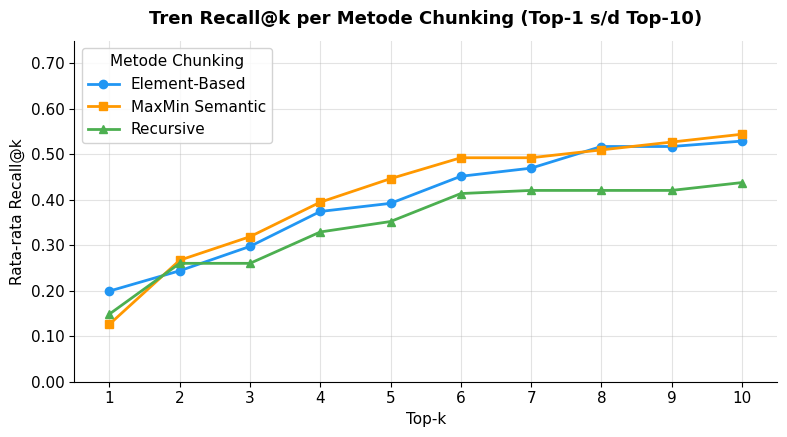

In [3]:
trend = (
    all_df
    .groupby(["top_k", "method"])[["recall_at_k", "mrr"]]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))

for method in METHOD_ORDER:
    d = trend[trend["method"] == method].sort_values("top_k")
    ax.plot(
        d["top_k"], d["recall_at_k"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2, markersize=6,
        label=method,
    )

ax.set_xlabel("Top-k")
ax.set_ylabel("Rata-rata Recall@k")
ax.set_title("Tren Recall@k per Metode Chunking (Top-1 s/d Top-10)", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, 0.75)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(title="Metode Chunking", framealpha=0.85)

fig.tight_layout()
save_fig(fig, "01_recall_trend.png")

---
## Chart 2 — Tren MRR per Metode (Top-1 s/d Top-10)

Tersimpan: ..\results\final\figures\02_mrr_trend.png


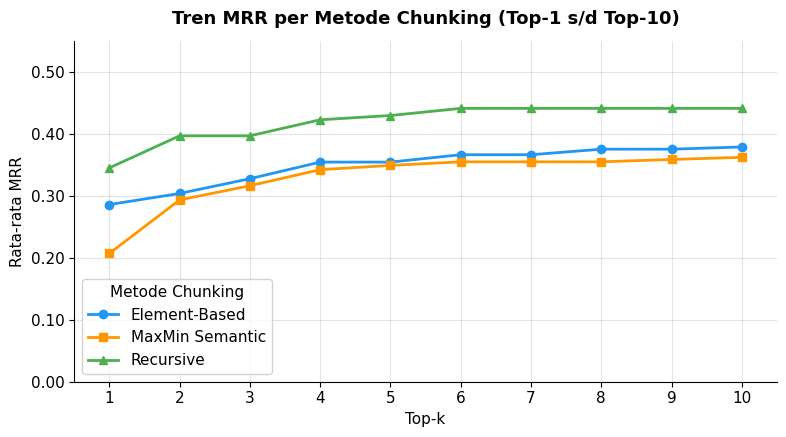

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for method in METHOD_ORDER:
    d = trend[trend["method"] == method].sort_values("top_k")
    ax.plot(
        d["top_k"], d["mrr"],
        color=METHOD_COLORS[method],
        marker=METHOD_MARKERS[method],
        linewidth=2, markersize=6,
        label=method,
    )

ax.set_xlabel("Top-k")
ax.set_ylabel("Rata-rata MRR")
ax.set_title("Tren MRR per Metode Chunking (Top-1 s/d Top-10)", fontsize=13, fontweight="bold", pad=12)
ax.set_xticks(range(1, 11))
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, 0.55)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(title="Metode Chunking", framealpha=0.85)

fig.tight_layout()
save_fig(fig, "02_mrr_trend.png")

---
## Chart 3 — Rata-rata BLEU & ROUGE-L per Metode (Top-5)

Tersimpan: ..\results\final\figures\03_bleu_rouge_bar.png


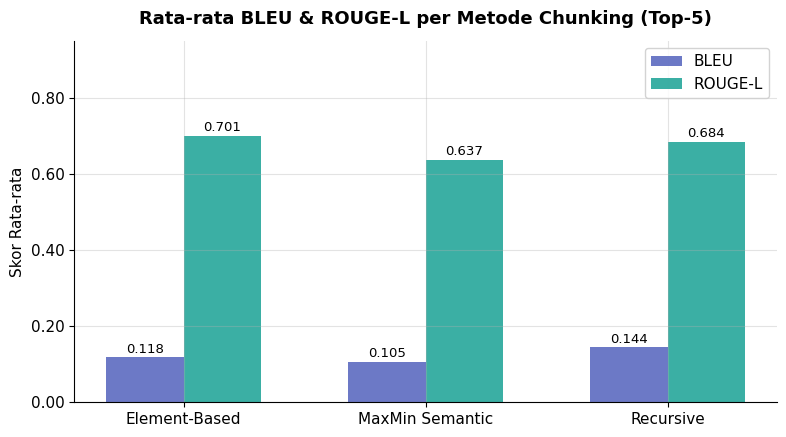

In [5]:
top5 = all_df[all_df["top_k"] == 5].copy()

gen_avg = (
    top5
    .groupby("method")[["bleu", "rouge_l_recall"]]
    .mean()
    .reindex(METHOD_ORDER)
    .reset_index()
)

x      = np.arange(len(METHOD_ORDER))
width  = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))

bars_bleu  = ax.bar(x - width/2, gen_avg["bleu"],          width, label="BLEU",   color="#5C6BC0", alpha=0.9)
bars_rouge = ax.bar(x + width/2, gen_avg["rouge_l_recall"], width, label="ROUGE-L", color="#26A69A", alpha=0.9)

# Tambah label nilai di atas bar
for bar in bars_bleu:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9.5)
for bar in bars_rouge:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9.5)

ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Skor Rata-rata")
ax.set_title("Rata-rata BLEU & ROUGE-L per Metode Chunking (Top-5)", fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(framealpha=0.85)

fig.tight_layout()
save_fig(fig, "03_bleu_rouge_bar.png")

---
## Chart 4 — Jumlah Query Berhasil Di-retrieve (MRR > 0) per Metode per Top-k

Tersimpan: ..\results\final\figures\04_retrieval_hit_count.png

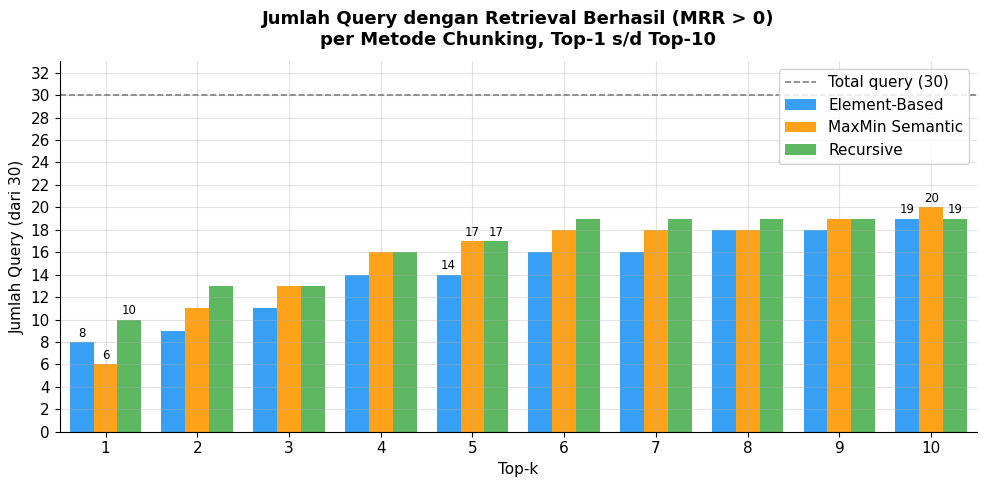

In [6]:
hit_df = (
    all_df[all_df["mrr"] > 0]
    .groupby(["top_k", "method"])["query_id"]
    .count()
    .unstack()
    .reindex(columns=METHOD_ORDER)
)

total_queries = all_df["query_id"].nunique()   # 30

x     = np.arange(1, 11)   # top-k 1..10
width = 0.26
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(10, 5))

for i, method in enumerate(METHOD_ORDER):
    bars = ax.bar(
        x + offsets[i], hit_df[method], width,
        label=method,
        color=METHOD_COLORS[method], alpha=0.9,
    )
    # Label nilai di atas bar (hanya top-1 dan top-10 agar tidak penuh)
    for j, bar in enumerate(bars):
        if x[j] in (1, 5, 10):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    str(int(bar.get_height())), ha="center", va="bottom", fontsize=8.5)

# Garis total query
ax.axhline(total_queries, color="gray", linestyle="--", linewidth=1.2, label=f"Total query ({total_queries})")

ax.set_xlabel("Top-k")
ax.set_ylabel("Jumlah Query (dari 30)")
ax.set_title(
    "Jumlah Query dengan Retrieval Berhasil (MRR > 0)\nper Metode Chunking, Top-1 s/d Top-10",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xticks(x)
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0, total_queries + 3)
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
ax.legend(framealpha=0.85)

fig.tight_layout()
save_fig(fig, "04_retrieval_hit_count.png")

---
## Chart 5 — Heatmap MRR per Query per Metode (Top-5)

Tersimpan: ..\results\final\figures\05_mrr_heatmap.png


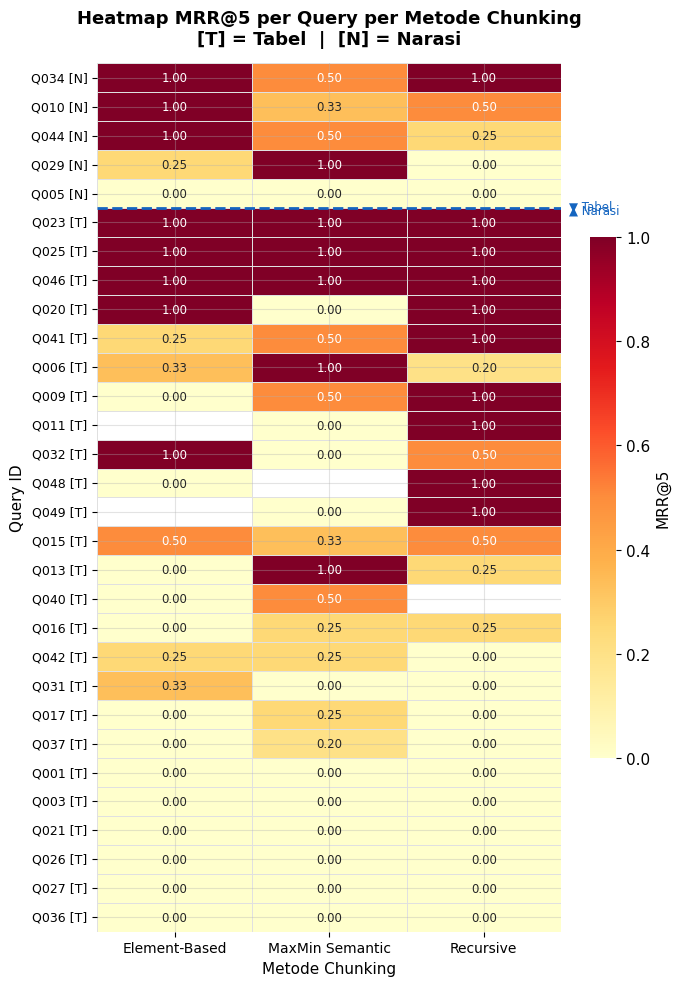

In [7]:
# Load QA pairs untuk label tipe (tabel / narasi)
qa_path = ROOT / "data" / "ground_truth" / "qa_pairs_binary.json"
with open(qa_path, encoding="utf-8") as f:
    qa_list = json.load(f)

NARASI_KW = ["apa yang dimaksud", "jelaskan", "bagaimana", "ke dalam kelompok", "apa saja", "apa yang"]
def classify(q):
    ql = q.lower()
    return "narasi" if any(kw in ql for kw in NARASI_KW) else "tabel"

qa_type  = {item["id"]: classify(item["question"]) for item in qa_list}

# Pivot: baris = query_id, kolom = method, nilai = MRR@5
heat_df = (
    top5
    .pivot_table(index="query_id", columns="method", values="mrr", aggfunc="mean")
    .reindex(columns=METHOD_ORDER)
)

# Urutkan: narasi dulu, lalu tabel; di dalam grup urutkan berdasarkan MRR rata-rata
heat_df["type"] = heat_df.index.map(qa_type)
heat_df["mean_mrr"] = heat_df[METHOD_ORDER].mean(axis=1)
heat_df = heat_df.sort_values(["type", "mean_mrr"], ascending=[True, False])

# Pisahkan label tipe untuk anotasi sumbu y
y_labels = [
    f"{qid} [{heat_df.loc[qid,'type'][0].upper()}]"   # e.g. Q010 [N]
    for qid in heat_df.index
]
plot_data = heat_df[METHOD_ORDER].astype(float)

fig, ax = plt.subplots(figsize=(7, 10))

sns.heatmap(
    plot_data,
    ax=ax,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8.5},
    linewidths=0.4, linecolor="#e0e0e0",
    cbar_kws={"label": "MRR@5", "shrink": 0.6},
    yticklabels=y_labels,
)

ax.set_title(
    "Heatmap MRR@5 per Query per Metode Chunking\n"
    "[T] = Tabel  |  [N] = Narasi",
    fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlabel("Metode Chunking")
ax.set_ylabel("Query ID")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)

# Separator visual: garis horizontal antara narasi & tabel
n_narasi = (heat_df["type"] == "narasi").sum()
ax.axhline(n_narasi, color="#1565C0", linewidth=2, linestyle="--")
ax.text(3.05, n_narasi - 0.15, "▲ Narasi", color="#1565C0", fontsize=8.5, va="top")
ax.text(3.05, n_narasi + 0.15, "▼ Tabel",  color="#1565C0", fontsize=8.5, va="bottom")

fig.tight_layout()
save_fig(fig, "05_mrr_heatmap.png")

---
## Bonus Chart 6 — Radar Chart Perbandingan Metrik per Metode (Top-5)

Menampilkan semua metrik (Precision, Recall, MRR, BLEU, ROUGE-L) sekaligus dalam satu gambar — cocok untuk ringkasan di bagian kesimpulan laporan.

Tersimpan: ..\results\final\figures\06_radar_all_metrics.png


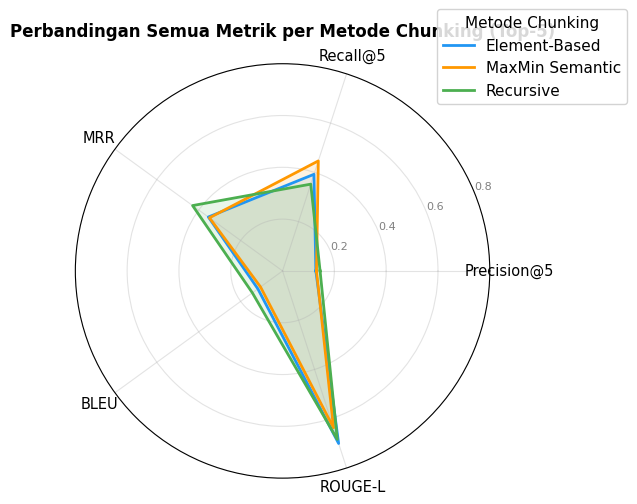

In [8]:
metrics_avg = (
    top5
    .groupby("method")[["precision_at_k", "recall_at_k", "mrr", "bleu", "rouge_l_recall"]]
    .mean()
    .reindex(METHOD_ORDER)
)

LABELS = ["Precision@5", "Recall@5", "MRR", "BLEU", "ROUGE-L"]
N      = len(LABELS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # tutup polygon

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for method in METHOD_ORDER:
    values = metrics_avg.loc[method].tolist()
    values += values[:1]
    ax.plot(angles, values, color=METHOD_COLORS[method], linewidth=2, label=method)
    ax.fill(angles, values, color=METHOD_COLORS[method], alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(LABELS, fontsize=10.5)
ax.set_ylim(0, 0.8)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8, color="gray")
ax.set_title(
    "Perbandingan Semua Metrik per Metode Chunking (Top-5)",
    fontsize=12, fontweight="bold", pad=20,
)
ax.legend(
    title="Metode Chunking",
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15),
    framealpha=0.85,
)

fig.tight_layout()
save_fig(fig, "06_radar_all_metrics.png")

---
## Ringkasan Skor (Tabel Numerik Top-5)

In [9]:
summary = (
    top5
    .groupby("method")[["precision_at_k", "recall_at_k", "mrr", "bleu", "rouge_l_recall"]]
    .mean()
    .reindex(METHOD_ORDER)
    .rename(columns={
        "precision_at_k": "Precision@5",
        "recall_at_k":    "Recall@5",
        "mrr":            "MRR",
        "bleu":           "BLEU",
        "rouge_l_recall": "ROUGE-L",
    })
    .round(4)
)
summary.index.name = "Metode"

print("=== Ringkasan Metrik Rata-rata Top-5 ===")
display(summary.style.highlight_max(color="#c8e6c9", axis=0).format("{:.4f}"))

# Simpan juga ke CSV
summary.to_csv(FIG_DIR / "summary_metrics_top5.csv")
print(f"\nTersimpan: {FIG_DIR / 'summary_metrics_top5.csv'}")

=== Ringkasan Metrik Rata-rata Top-5 ===


,Precision@5,Recall@5,MRR,BLEU,ROUGE-L
Metode,,,,,
Element-Based,0.1286,0.3923,0.3542,0.1178,0.7005
MaxMin Semantic,0.1310,0.4466,0.3488,0.1052,0.6369
Recursive,0.1448,0.3523,0.4293,0.1440,0.6838



Tersimpan: ..\results\final\figures\summary_metrics_top5.csv
